<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/ETF_Investing_BackTesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta
!pip install --upgrade backtrader

In [157]:
import yfinance as yf
import pandas as pd
import numpy as np
import logging
import backtrader as bt
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.optimize import minimize
from scipy.stats import zscore

%matplotlib inline
print("Libraries Installed!")

Libraries Installed!


## Create Class for Backtesting

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Initial Portfolio Value: 10000
Top 3 ETFs as of 2023-07-05: ['QQQ', 'XLY', 'XLK']
Current positions: []
New top ETFs: ['QQQ', 'XLY', 'XLK']
ETFs to sell: []
Current portfolio value: 10000.00
Allocation per ETF: 3333.33
Bought 9 shares of QQQ at 366.63
Bought 19 shares of XLY at 169.91
Bought 19 shares of XLK at 170.50
Top 3 ETFs as of 2023-09-06: ['XLK', 'QQQ', 'XLY']
Current positions: ['QQQ', 'XLK', 'XLY']
New top ETFs: ['XLK', 'QQQ', 'XLY']
ETFs to sell: []
Current portfolio value: 10125.22
Allocation per ETF: 3375.07
Keeping existing position for XLK
Keeping existing position for QQQ
Keeping existing position for XLY
Top 3 ETFs as of 2023-11-08: ['XLK', 'QQQ', 'SPY']
Current positions: ['QQQ', 'XLK', 'XLY']
New top ETFs: ['XLK', 'QQQ', 'SPY']
ETFs to sell: ['XLY']
Closed position for XLY
Current portfolio value: 10019.62
Allocation per ETF: 3339.87
Keeping existing position for XLK
Keeping existing position for QQQ
Bought 7 shares of SPY at 429.97
Top 3 ETFs as of 2024-01-10: ['IYG

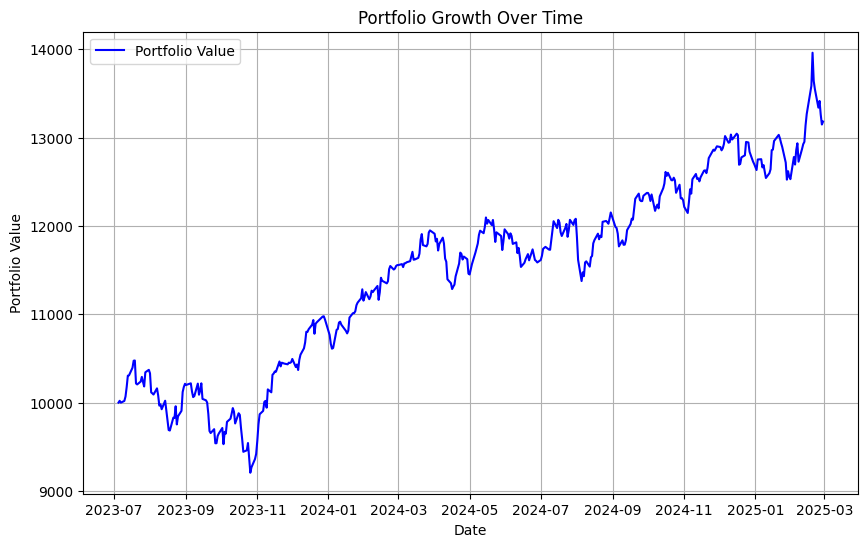

In [160]:
from mmap import ALLOCATIONGRANULARITY
import backtrader as bt
import pandas as pd

# Define the ETFRotationStrategy class with the required methods
class ETFRotationStrategy(bt.Strategy):
    top_n = 3 # Number of top ETFs to select and allocate equally
    rebalance_interval = 63 #~ ~63 trading days for a quartely rebalance

    def __init__(self):
        self.last_rebalance = None
        self.top_etfs = []
        self.initial_value = None
        self.portfolio_values = []  # Store portfolio values over time

    def start(self):
      # Set the initial portfolio value
      self.initial_value = self.broker.get_value()
      print(f"Initial Portfolio Value: {self.initial_value}")

    def getdatabyname(self, ticker):
        """Find the corresponding data feed for the given ticker."""
        try:
            for data in self.datas:
                if data._name == ticker:
                    return data
        except Exception as e:
            print(f"Error getting data for {ticker}: {e}")
        return None

    def calculate_normalized_score(self, ticker):
        """Calculate normalized score using 1M, 3M, 6M performance."""
        try:
            data = self.getdatabyname(ticker)
            if data is None:
                print(f"No data found for {ticker}")
                return None
            if len(data) < 126:
                print(f"Not enough data for {data._name}")
                return None

            # Retrieve the historical close prices
            close_1m = data.close.get(size=21)
            close_3m = data.close.get(size=63)
            close_6m = data.close.get(size=126)

             # Ensure sufficient data is returned
            if len(close_1m) < 21 or len(close_3m) < 63 or len(close_6m) < 126:
              print(f"Not enough data to calculate z-scores for {data._name}")
              return None

            # Calculate raw performance
            price_1m = close_1m[-1] / close_1m[0] - 1
            price_3m = close_3m[-1] / close_3m[0] - 1
            price_6m = close_6m[-1] / close_6m[0] - 1

            # Convert to numpy arrays for easier calculation
            close_1m_np = np.array(close_1m)
            close_3m_np = np.array(close_3m)
            close_6m_np = np.array(close_6m)

            # Calculate z-scores using numpy
            mean_1m, std_1m = np.mean(close_1m_np), np.std(close_1m_np)
            mean_3m, std_3m = np.mean(close_3m_np), np.std(close_3m_np)
            mean_6m, std_6m = np.mean(close_6m_np), np.std(close_6m_np)

            # Avoid deivision by zero
            std_1m = std_1m if std_1m > 0 else 1e-10
            std_3m = std_3m if std_3m > 0 else 1e-10
            std_6m = std_6m if std_6m > 0 else 1e-10

            # Compute the zscore
            zscore_1m = (price_1m - mean_1m) / std_1m
            zscore_3m = (price_3m - mean_3m) / std_3m
            zscore_6m = (price_6m - mean_6m) / std_6m


            score = 0.33 * price_1m + 0.33 * price_3m + 0.33 * price_6m
            #score = 0.8 * zscore_1m + 0.3 * zscore_3m + 0.1 * zscore_6m
            return score
        except Exception as e:
            print(f"Error calculating score for {ticker}: {e}")
            return None

    def rebalance_portfolio(self):
      """ """
      try:

        # Close existing positions if not in next top_n etfs
        current_positions = [data._name for data in self.datas if self.getposition(data).size > 0]
        print(f"Current positions: {current_positions}")
        print(f"New top ETFs: {self.top_etfs}")

        # Identify ETFs to sell (not in the new top ETFs)
        etfs_to_sell = [ticker for ticker in current_positions if ticker not in self.top_etfs]
        print(f"ETFs to sell: {etfs_to_sell}")

        for ticker in etfs_to_sell:
          data = self.getdatabyname(ticker)
          if data:
            self.close(data=data)
            print(f"Closed position for {data._name}")


        #for data in self.datas:
          #position = self.getposition(data)
          #if position.size > 0:
            #self.close(data)
            #print(f"Closed position for {data._name}")

        # Allocate remaining portfolio value across new top ETFs
        portfolio_value = self.broker.getvalue()
        allocation = portfolio_value/len(self.top_etfs)
        print(f"Current portfolio value: {portfolio_value:.2f}")
        print(f"Allocation per ETF: {allocation:.2f}")

        # Buy the top ETFs
        for ticker in self.top_etfs:
          data = self.getdatabyname(ticker)
          if data:
            price = data.close[0]
            position = self.getposition(data)
            if position.size == 0: # Buy new positions
              shares = int(allocation / price)
              self.buy(data=data, size=shares)
              print(f"Bought {shares} shares of {ticker} at {price:.2f}")
            else:
              print(f"Keeping existing position for {ticker}")
      except Exception as e:
        print(f"Error in rebalance_portfolio: {e}")

    def stop(self):
      """ Stop method """
      try:
        # Calculate the final portfolio value
        final_value = self.broker.get_value()

        # Ensure initial portfolio value is stored
        if not hasattr(self, 'initial_value'):
          print("Error: Initial portfolio value not set!")
          return

        # Calculate the growth percentage
        growth_percentage = ((final_value - self.initial_value) / self.initial_value) * 100

        # Display the results
        print(f"Initial Portfolio Value: {self.initial_value:.2f}")
        print(f"Final Portfolio Value: {final_value:.2f}")
        print(f"Portfolio Growth: {growth_percentage:.2f}%")

        # Plot the portfolio growth
        dates, values = zip(*self.portfolio_values)  # Unpack dates and values
        plt.figure(figsize=(10, 6))
        plt.plot(dates, values, label='Portfolio Value', color='blue')
        plt.xlabel('Date')
        plt.ylabel('Portfolio Value')
        plt.title('Portfolio Growth Over Time')
        plt.legend()
        plt.grid()
        plt.show()

      except Exception as e:
        print(f"Error in stop: {e}")

    def next(self):
      try:
        # Debugging: Print available data names to check if they are strings or tuples
        #print("Available data names:", self.getdatanames())

        # Skip the warm-up period (first 126 trading days)
        if len(self.datas[0]) <126:
          return # Do nothing until enough data is available

        # Record the initial value at the start of the backtest
        #if self.initial_value is None:
            #self.initial_value = self.broker.get_value()

        # Record the portfolio value at each step
        current_value = self.broker.getvalue()
        self.portfolio_values.append((self.datetime.date(), current_value))

        # Rebalance portfolo every quarter
        if self.last_rebalance is None or (self.datetime.date() - self.last_rebalance).days >= self.rebalance_interval:
          self.last_rebalance = self.datetime.date()

          # Get the performance for each ETF
          etf_scores =[(data._name, self.calculate_normalized_score(data._name))
                for data in self.datas ]
          # sort ETFs by score in descending order and select top_m

          self.top_etfs = [
                ticker for ticker, score in sorted(etf_scores, key=lambda x: x[1], reverse=True)[:self.top_n]
            ]
          # Log the top ETFs
          print(f"Top {self.top_n} ETFs as of {self.datetime.date()}: {self.top_etfs}")
          self.rebalance_portfolio()
      except Exception as e:
        print(f"Error in next(): {e}")

# Function to set up and run the test
def run_test():
    cerebro = bt.Cerebro()
    # Set up the broker (optional but recommended)
    cerebro.broker.set_cash(10000)  # Starting cash for the backtest
    cerebro.broker.setcommission(commission=0.)  # Commission per trade
    # Set the position size to overide default sizing i.e. The number of units bought = cash available / asset price
    #cerebro.addsizer(bt.sizers.FixedSize, stake=100)

    # Create dummy data for two ETFs
    tickers = ['SPY', 'QQQ', 'DIA', 'IWM', 'XLK', 'XLF', 'XLY', 'XLP', 'XLU', 'XLV','IYG', 'EWH', 'VGK', 'EWO', 'UNG','FEZ']
    for ticker in tickers:
        df =  yf.download(ticker, start='2023-01-01', end='2025-03-01')
        df.columns = df.columns.droplevel(1)  # Drop the ticker symbol from column names
        data = bt.feeds.PandasData(dataname=df, name=ticker)
        cerebro.adddata(data)

    # Add the strategy to Cerebro
    cerebro.addstrategy(ETFRotationStrategy)

    #Run the Cerebro engine to trigger the `next` method
    cerebro.run()

    # Run the Cerebro engine to trigger the `next` method and retrieve the strategy instance
    #strategies = cerebro.run()  # This returns a tuple of strategy instances
    #strategy = strategies[0]  # Access the first strategy instance

    # Test `calculate_normalized_score` on the ETF list
    #for ticker in tickers:
        #score = strategy.calculate_normalized_score(ticker)
        #print(f"Calculated normalized score for {ticker}: {score}")


# Execute the test
if __name__ == "__main__":
    run_test()


QA Tests

## Test Strategy

In [105]:
from typing_extensions import final
import backtrader as bt
import yfinance as yf
import pandas as pd

# Create a strategy
class MyStrategy(bt.Strategy):
    def __init__(self):
        # Use built-in Simple Moving Average (SMA) as an example
        self.sma = bt.indicators.SimpleMovingAverage(self.data.close, period=200)
        self.crossover = bt.indicators.CrossOver(self.data.close, self.sma)
        self.initial_value = None

    def next(self):
        # Record the initial value at the start of the backtest
        if self.initial_value is None:
            self.initial_value = self.broker.get_value()

        # Buy if crossover happens and no position is open
        if self.crossover > 0 and not self.position:
            self.buy()

        # Sell if price falls below SMA
        elif self.crossover < 0 and self.position:
            self.sell()

    def stop(self):
        # Calculate portfolio growth percentage at the end of the backtest
        final_value = self.broker.get_value()
        #initial_value = self.broker.startingcash
        growth_percentage = ((final_value - self.initial_value) / self.initial_value) * 100
        print(f"Portfolio Growth: {growth_percentage:.2f}%")

# Set up the backtest
if __name__ == "__main__":
    # Create a Cerebro engine
    cerebro = bt.Cerebro()

    # Fetch data from Yahoo Finance using yfinance
    df = yf.download('VTI', start='2020-01-01', end='2025-01-01')

    # Resample the data to weekly frequency
    #df = df.resample('W').last()  # Resampling to weekly using the last price of the week

    # Flatten the columns by renaming to remove the multi-level index
    df.columns = df.columns.droplevel(1)  # Drop the ticker symbol from column names
    # Print columns to ensure the DataFrame is correct
    #print("Columns in the DataFrame:", df.columns)


    # Check if the dataframe has the correct columns (adjust column names if necessary)
    if set(['Open', 'High', 'Low', 'Close', 'Volume']).issubset(df.columns):
        # Add the data to Cerebro
        data = bt.feeds.PandasData(dataname=df)
        cerebro.adddata(data)

        # Add the strategy
        cerebro.addstrategy(MyStrategy)

        # Set up the broker (optional but recommended)
        cerebro.broker.set_cash(100000)  # Starting cash for the backtest
        cerebro.broker.setcommission(commission=0.)  # Commission per trade
        # Set the position size
        cerebro.addsizer(bt.sizers.FixedSize, stake=100)

        # Print the starting cash
        print(f"Starting Portfolio Value\t: {cerebro.broker.getvalue()}")

        # Run the backtest
        cerebro.run()

        # Plot the result
        cerebro.plot()

        # Print the final portfolio value
        print(f"Final Portfolio Value: {cerebro.broker.getvalue()}")
    else:
        print("Data is missing required columns.")


[*********************100%***********************]  1 of 1 completed


Starting Portfolio Value	: 100000
Portfolio Growth: 5.99%
Final Portfolio Value: 105989.99866453795
